# Análise Exploratória de Dados (EDA) - Telemarketing JYB Dataset

Este notebook tem como objetivo analisar a base de dados de campanhas bancárias pré-processada. O foco desta etapa é comprovar o desbalanceamento da variável alvo (conversão) e estabelecer os perfis de clientes que servirão de "Contexto" para a nossa plataforma de Multi-Armed Bandit (MAB).

## Dicionário de Dados (Amostra)
* **age**: Idade do cliente.
* **job**: Profissão.
* **marital**: Estado civil.
* **education**: Nível de escolaridade.
* **default**: Possui crédito em incumprimento? (yes/no)
* **housing**: Possui crédito habitação? (yes/no)
* **loan**: Possui crédito pessoal? (yes/no)
* **campaign**: Número de contatos nesta campanha.
* **y (Target)**: Subscreveu o depósito a prazo? (yes/no)

> **Nota de Governança sobre Data Leakage:** > Durante a validação da base original, confirmamos que a variável de vazamento temporal (`duration` da chamada) já foi devidamente descartada pela fonte e removida pela nossa pipeline de ingestão. A base reflete um cenário realista onde a decisão da oferta ocorre *antes* de sabermos a duração do contato.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_DIR = Path("../data/processed").resolve()
TRAIN_FILE = DATA_DIR / "train_clean.csv"

print(f"A ler dados higienizados de: {TRAIN_FILE}")
df = pd.read_csv(TRAIN_FILE)

display(df.head())

A ler dados higienizados de: C:\code\datathon-7mlet-grupo-75\data\processed\train_clean.csv


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,52,technician,married,high.school,no,yes,no,cellular,nov,tue,1,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
1,33,admin.,single,university.degree,no,yes,no,cellular,nov,thu,1,999,0,nonexistent,-0.1,93.200,-42.0,4.076,5195.8,no
2,54,admin.,single,university.degree,no,yes,no,cellular,may,mon,1,999,0,nonexistent,-1.8,92.893,-46.2,1.264,5099.1,no
3,53,housemaid,married,high.school,no,no,yes,cellular,jun,thu,1,999,2,failure,-2.9,92.963,-40.8,1.260,5076.2,yes
4,42,self-employed,married,university.degree,unknown,yes,no,cellular,aug,tue,2,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no


## O Problema das Regras Estáticas (Desbalanceamento)
Uma instituição financeira não pode depender de regras fixas de marketing porque a grande maioria dos contatos não gera conversão. O gráfico abaixo prova matematicamente a necessidade de um algoritmo adaptativo que aprenda rapidamente quais ofertas funcionam para quais nichos, em vez de disparar campanhas genéricas.

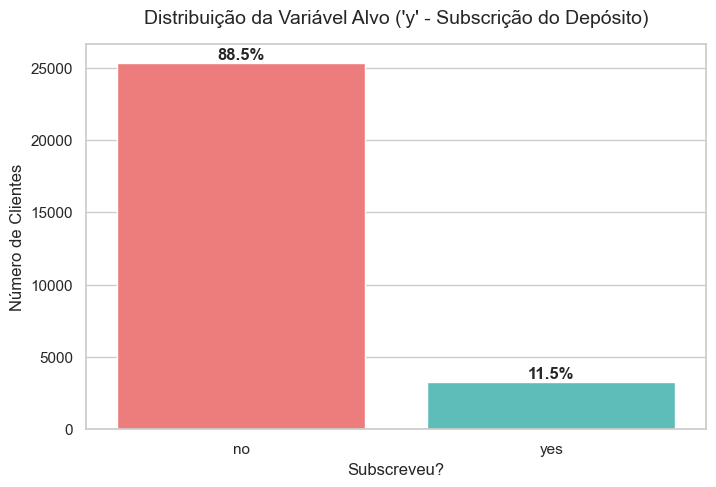

Conclusão: A taxa de conversão padrão ronda os 11%. Uma plataforma MAB é mandatória para otimizar este cenário.


In [7]:
target_counts = df["y"].value_counts()
target_percentages = df["y"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    ax=ax,
    hue=target_counts.index,
    palette=["#FF6B6B", "#4ECDC4"],
    legend=False,
)

ax.set_title(
    "Distribuição da Variável Alvo ('y' - Subscrição do Depósito)", fontsize=14, pad=15
)
ax.set_ylabel("Número de Clientes")
ax.set_xlabel("Subscreveu?")

for i, p in enumerate(ax.patches):
    ax.annotate(
        f"{target_percentages.iloc[i]:.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

plt.show()

print(
    "Conclusão: A taxa de conversão padrão ronda os 11%. Uma plataforma MAB é mandatória para otimizar este cenário."
)

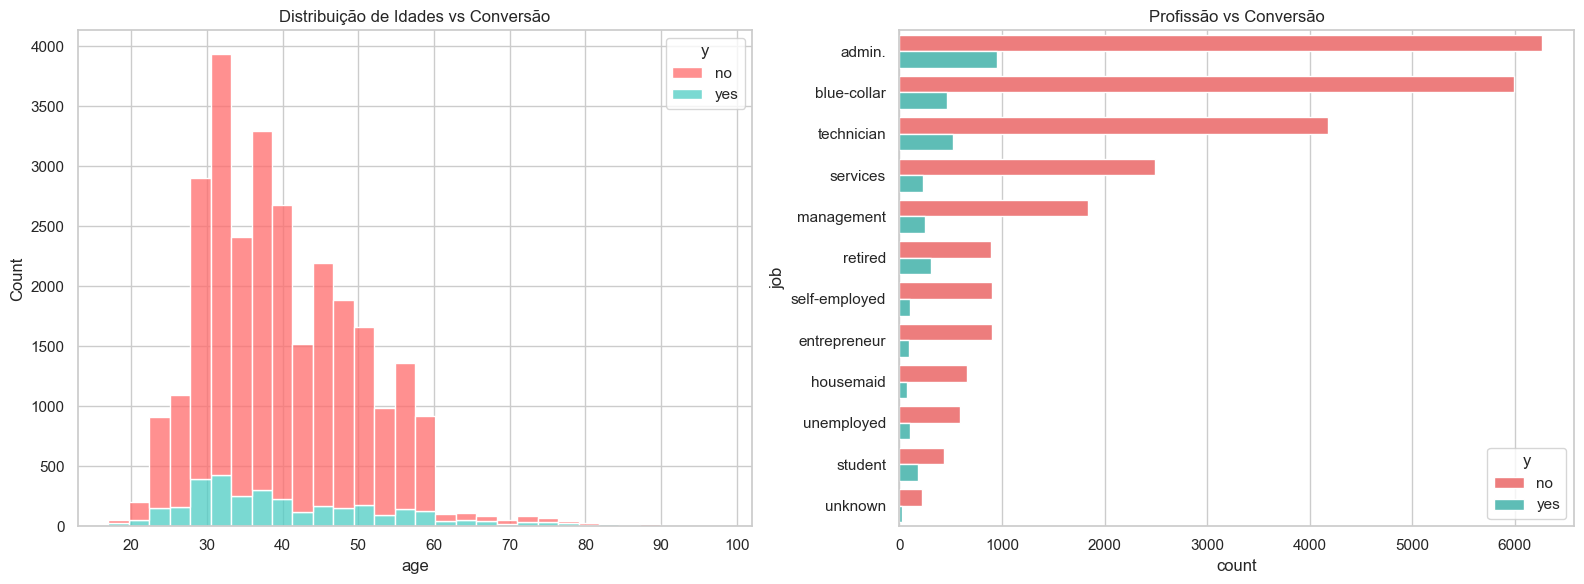

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    data=df,
    x="age",
    hue="y",
    bins=30,
    multiple="stack",
    ax=axes[0],
    palette=["#FF6B6B", "#4ECDC4"],
)
axes[0].set_title("Distribuição de Idades vs Conversão")

job_order = df["job"].value_counts().index
sns.countplot(
    data=df,
    y="job",
    hue="y",
    order=job_order,
    ax=axes[1],
    palette=["#FF6B6B", "#4ECDC4"],
)
axes[1].set_title("Profissão vs Conversão")

plt.tight_layout()
plt.show()